# Abstract:

In this Notebook, LSTM is applied to correlate/ predict whether the pump may be shut down (broken) for a period of time based on the input signal of the sensors.

The input parameters of the model used are the sensor parameters (in the database called sensors from 00 to 51). The output of the model is a single parameter: the pump operating state corresponding to 0 is the shutdown state, 1 is the normal operation state and 0.5 is recovering.

This Notebook will analyze the correlation between the input parameters (sensors) and determine which parameters are the most important, deciding on the output of the model, thereby building the simplest model, which requires less input parameters but the most accurate prediction results.

In [1]:
!pip install -q pandas
import pandas as pd
data =  pd.read_csv("sensor.csv")

# Step 1. Data cleaning

<h4> The author of the data set has reported that the system had 7 system failures over one year, which caused serious problems. Thus, the problem consists on predicting when will the next failure occur is very important. <h4>
    (www.kaggle.com/nphantawee/pump-sensor-data) 

In [2]:
data.shape

(220320, 55)

<h4> The data frame shows that, there are 55 columns with 220320 recordings. Moreover, the measurements have different scales, as following.<h4>

In [3]:
data.columns

Index(['Unnamed: 0', 'timestamp', 'sensor_00', 'sensor_01', 'sensor_02',
       'sensor_03', 'sensor_04', 'sensor_05', 'sensor_06', 'sensor_07',
       'sensor_08', 'sensor_09', 'sensor_10', 'sensor_11', 'sensor_12',
       'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17',
       'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'sensor_22',
       'sensor_23', 'sensor_24', 'sensor_25', 'sensor_26', 'sensor_27',
       'sensor_28', 'sensor_29', 'sensor_30', 'sensor_31', 'sensor_32',
       'sensor_33', 'sensor_34', 'sensor_35', 'sensor_36', 'sensor_37',
       'sensor_38', 'sensor_39', 'sensor_40', 'sensor_41', 'sensor_42',
       'sensor_43', 'sensor_44', 'sensor_45', 'sensor_46', 'sensor_47',
       'sensor_48', 'sensor_49', 'sensor_50', 'sensor_51', 'machine_status'],
      dtype='object')

In [4]:
data.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,220320.0,110159.50,63601.05,0.00,55079.75,110159.50,165239.25,220319.00
sensor_00,210112.0,2.37,0.41,0.00,2.44,2.46,2.50,2.55
sensor_01,219951.0,47.59,3.30,0.00,46.31,48.13,49.48,56.73
sensor_02,220301.0,50.87,3.67,33.16,50.39,51.65,52.78,56.03
sensor_03,220301.0,43.75,2.42,31.64,42.84,44.23,45.31,48.22
sensor_04,220301.0,590.67,144.02,2.80,626.62,632.64,637.62,800.00
sensor_05,220301.0,73.40,17.30,0.00,69.98,75.58,80.91,100.00
sensor_06,215522.0,13.50,2.16,0.01,13.35,13.64,14.54,22.25
sensor_07,214869.0,15.84,2.20,0.00,15.91,16.17,16.43,23.60
sensor_08,215213.0,15.20,2.04,0.03,15.18,15.49,15.70,24.35


## Missing Value

In [5]:
data.isna().sum().sort_values(ascending=True)

Unnamed: 0             0
timestamp              0
machine_status         0
sensor_28             16
sensor_23             16
sensor_19             16
sensor_21             16
sensor_27             16
sensor_24             16
sensor_34             16
sensor_37             16
sensor_36             16
sensor_33             16
sensor_35             16
sensor_31             16
sensor_20             16
sensor_10             19
sensor_11             19
sensor_03             19
sensor_02             19
sensor_04             19
sensor_05             19
sensor_12             19
sensor_13             19
sensor_26             20
sensor_14             21
sensor_39             27
sensor_44             27
sensor_41             27
sensor_40             27
sensor_43             27
sensor_42             27
sensor_49             27
sensor_47             27
sensor_48             27
sensor_38             27
sensor_46             27
sensor_45             27
sensor_16             31
sensor_25             36


In [6]:
# Calculate the percentage of missing values for each column
missing_percentage = (data.isnull().mean() * 100).round(2)
# Sort the values in ascending order
missing_percentage_sorted = missing_percentage.sort_values(ascending=True)

# Display the result
print("Percentage of Missing Values for Each Column (Ascending Order):")
print(missing_percentage_sorted)

Percentage of Missing Values for Each Column (Ascending Order):
Unnamed: 0          0.00
timestamp           0.00
machine_status      0.00
sensor_03           0.01
sensor_04           0.01
sensor_05           0.01
sensor_12           0.01
sensor_02           0.01
sensor_11           0.01
sensor_10           0.01
sensor_27           0.01
sensor_21           0.01
sensor_19           0.01
sensor_20           0.01
sensor_16           0.01
sensor_13           0.01
sensor_28           0.01
sensor_26           0.01
sensor_24           0.01
sensor_23           0.01
sensor_41           0.01
sensor_40           0.01
sensor_43           0.01
sensor_42           0.01
sensor_34           0.01
sensor_39           0.01
sensor_37           0.01
sensor_36           0.01
sensor_33           0.01
sensor_35           0.01
sensor_31           0.01
sensor_14           0.01
sensor_49           0.01
sensor_47           0.01
sensor_48           0.01
sensor_38           0.01
sensor_44           0.01
sensor_45  

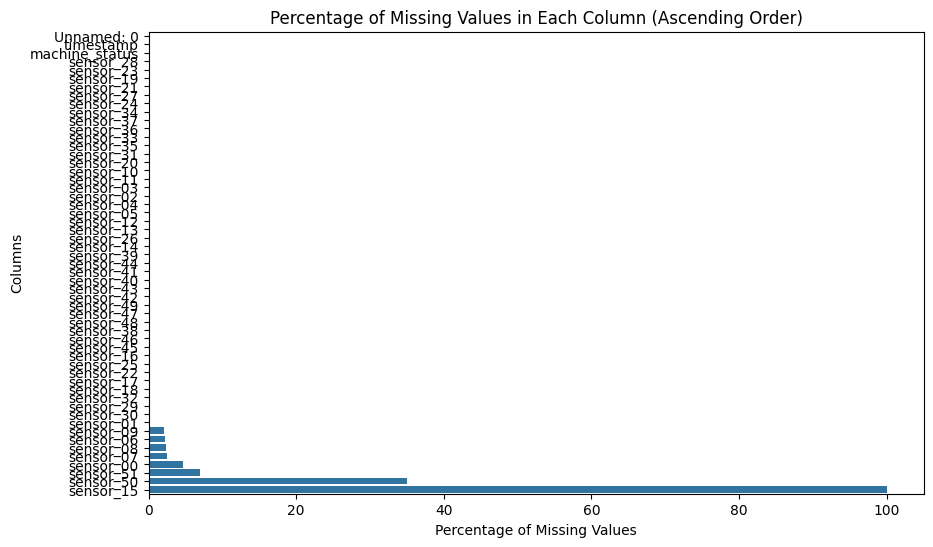

In [8]:
# Calculate the percentage of missing values for each column
missing_values_percentage = data.isnull().mean() * 100

# Now you can sort and visualize the missing values
missing_values_percentage_sorted = missing_values_percentage.sort_values()

# Visualization code
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values_percentage_sorted, y=missing_values_percentage_sorted.index)
plt.title('Percentage of Missing Values in Each Column (Ascending Order)')
plt.xlabel('Percentage of Missing Values')
plt.ylabel('Columns')
plt.show()

<Axes: >

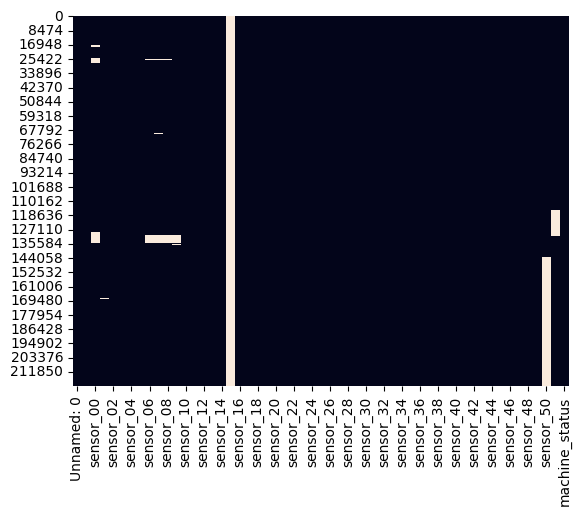

In [9]:
sns.heatmap(data.isnull(),cbar=False)

<h4> Let remove first all NaN columns and all columns have zero standard values.<h4>

In [10]:
data.drop(['Unnamed: 0', 'timestamp','sensor_00','sensor_15','sensor_50','sensor_51'],axis=1, inplace=True)

We need to note that, because sensors are not specifically noted what operating parameters, for example, pressure, temperature, flow, vibration, ... they measure. However, concretely and quickly making a judgment about which sensor will be the decisive parameter to the operating status and operation of the pump is very important. 

In actual operation, pump systems are often equipped with more than one sensor for a single operating parameter, such as pressure, flow rate or temperature, for a variety of reasons such as safety, operation or system reliability or automation equipment confidence. This can be the cause of the overlap in the measured signals of some sensors as analyzed following.

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
      dtype=object)

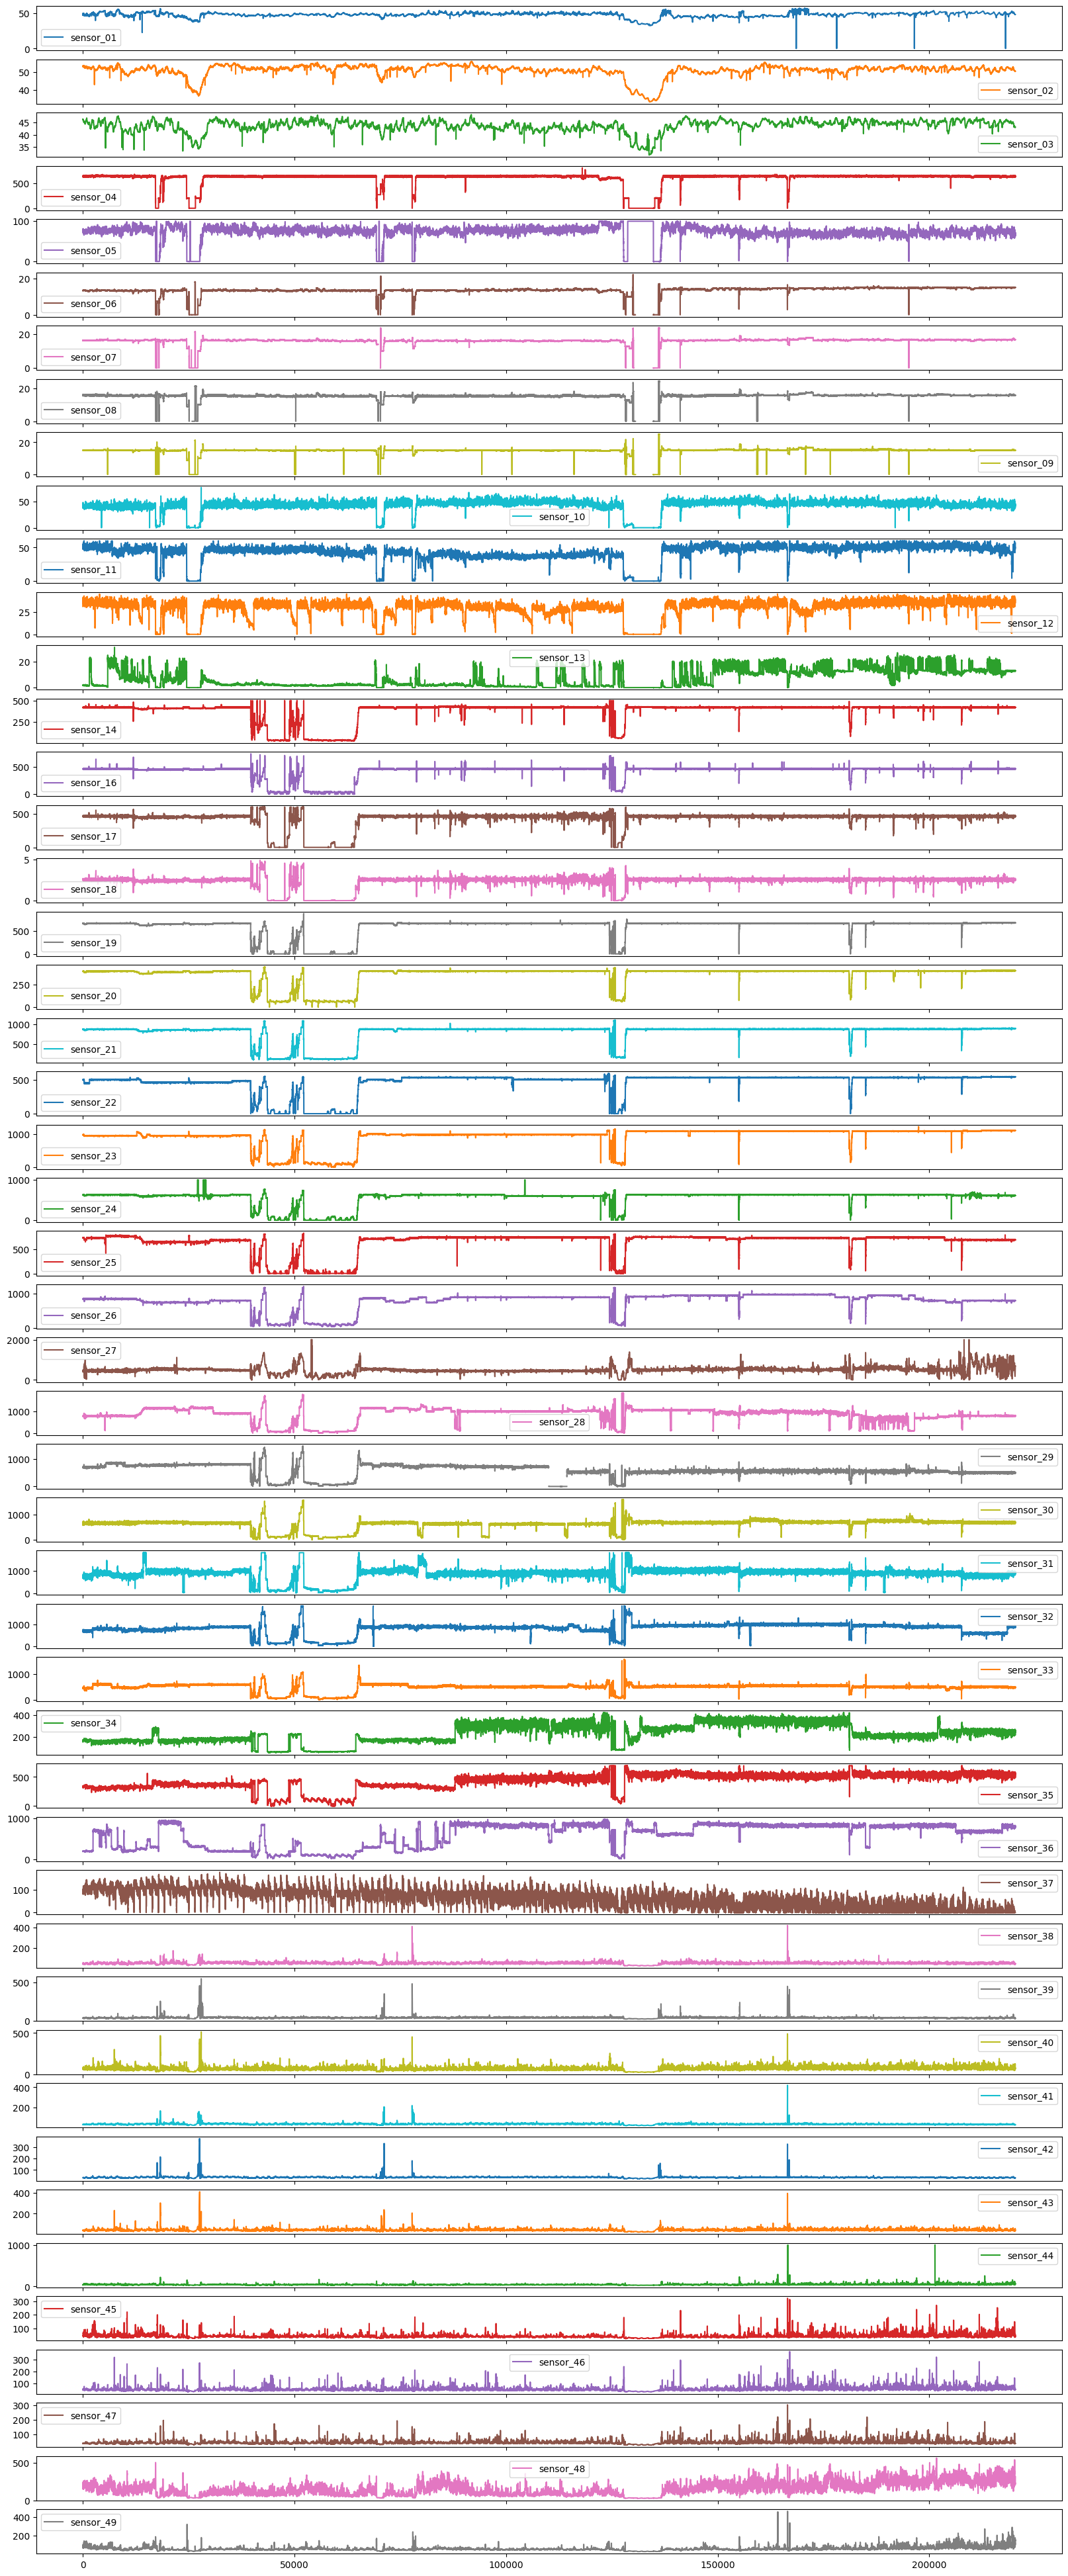

In [11]:
import matplotlib.pyplot as plt
data.plot(subplots =True, sharex = True, figsize = (20,50))

# As can be seen there are a pattern being captured by the sensors, example:

+ (1,2,3), 
+ (4,5,6,7,8,9),
+ (10,11,12), 
+ (14,16,17,18), 
+ (19,20,21,22,23,24), 
+ (25,26,28,29,30,31,32,33), 
+ (34,35), 
+ (38,39,40,41,42,43,45,46,47). 
    
In turn, there are signals that are very noisy and seem to follow no trend in particular.

On the basis of that analysis, determining which sensor signal influence the operating state of the pump is important for modeling. To optimize the model, we proceed to select the input parameters of the model according to the following hypotheses.

In [12]:
data['machine_status'].value_counts()

machine_status
NORMAL        205836
RECOVERING     14477
BROKEN             7
Name: count, dtype: int64

The database has 7 BROKEN states, which are then RECOVERED and returned to a NORMAL operating state. For the sack of simplicity, we can assume that 25% of the data could be used to train the model (covering 2 BROKEN states), the remaining 75% of the data is used to test the predictability of the model based on input parameters (covers 5 BROKEN points).

For graphical illustration purpose, we assume the BROKEN state transitions have a value of 0, the RECOVERING state and NORMAL operation value 0.5 and 1, respectively and converted it into a new column named: "Operation".

In [13]:
import numpy as np
conditions = [(data['machine_status'] =='NORMAL'), (data['machine_status'] =='BROKEN'), (data['machine_status'] =='RECOVERING')]
choices = [1, 0, 0.5]
data['Operation'] = np.select(conditions, choices, default=0)

In order to check if there is some obvious patterns that could be landmarked in a certain period, we have added the "Operation" code in the illustrations. That could helps us to define a good dataset to fitthe model.

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >], dtype=object)

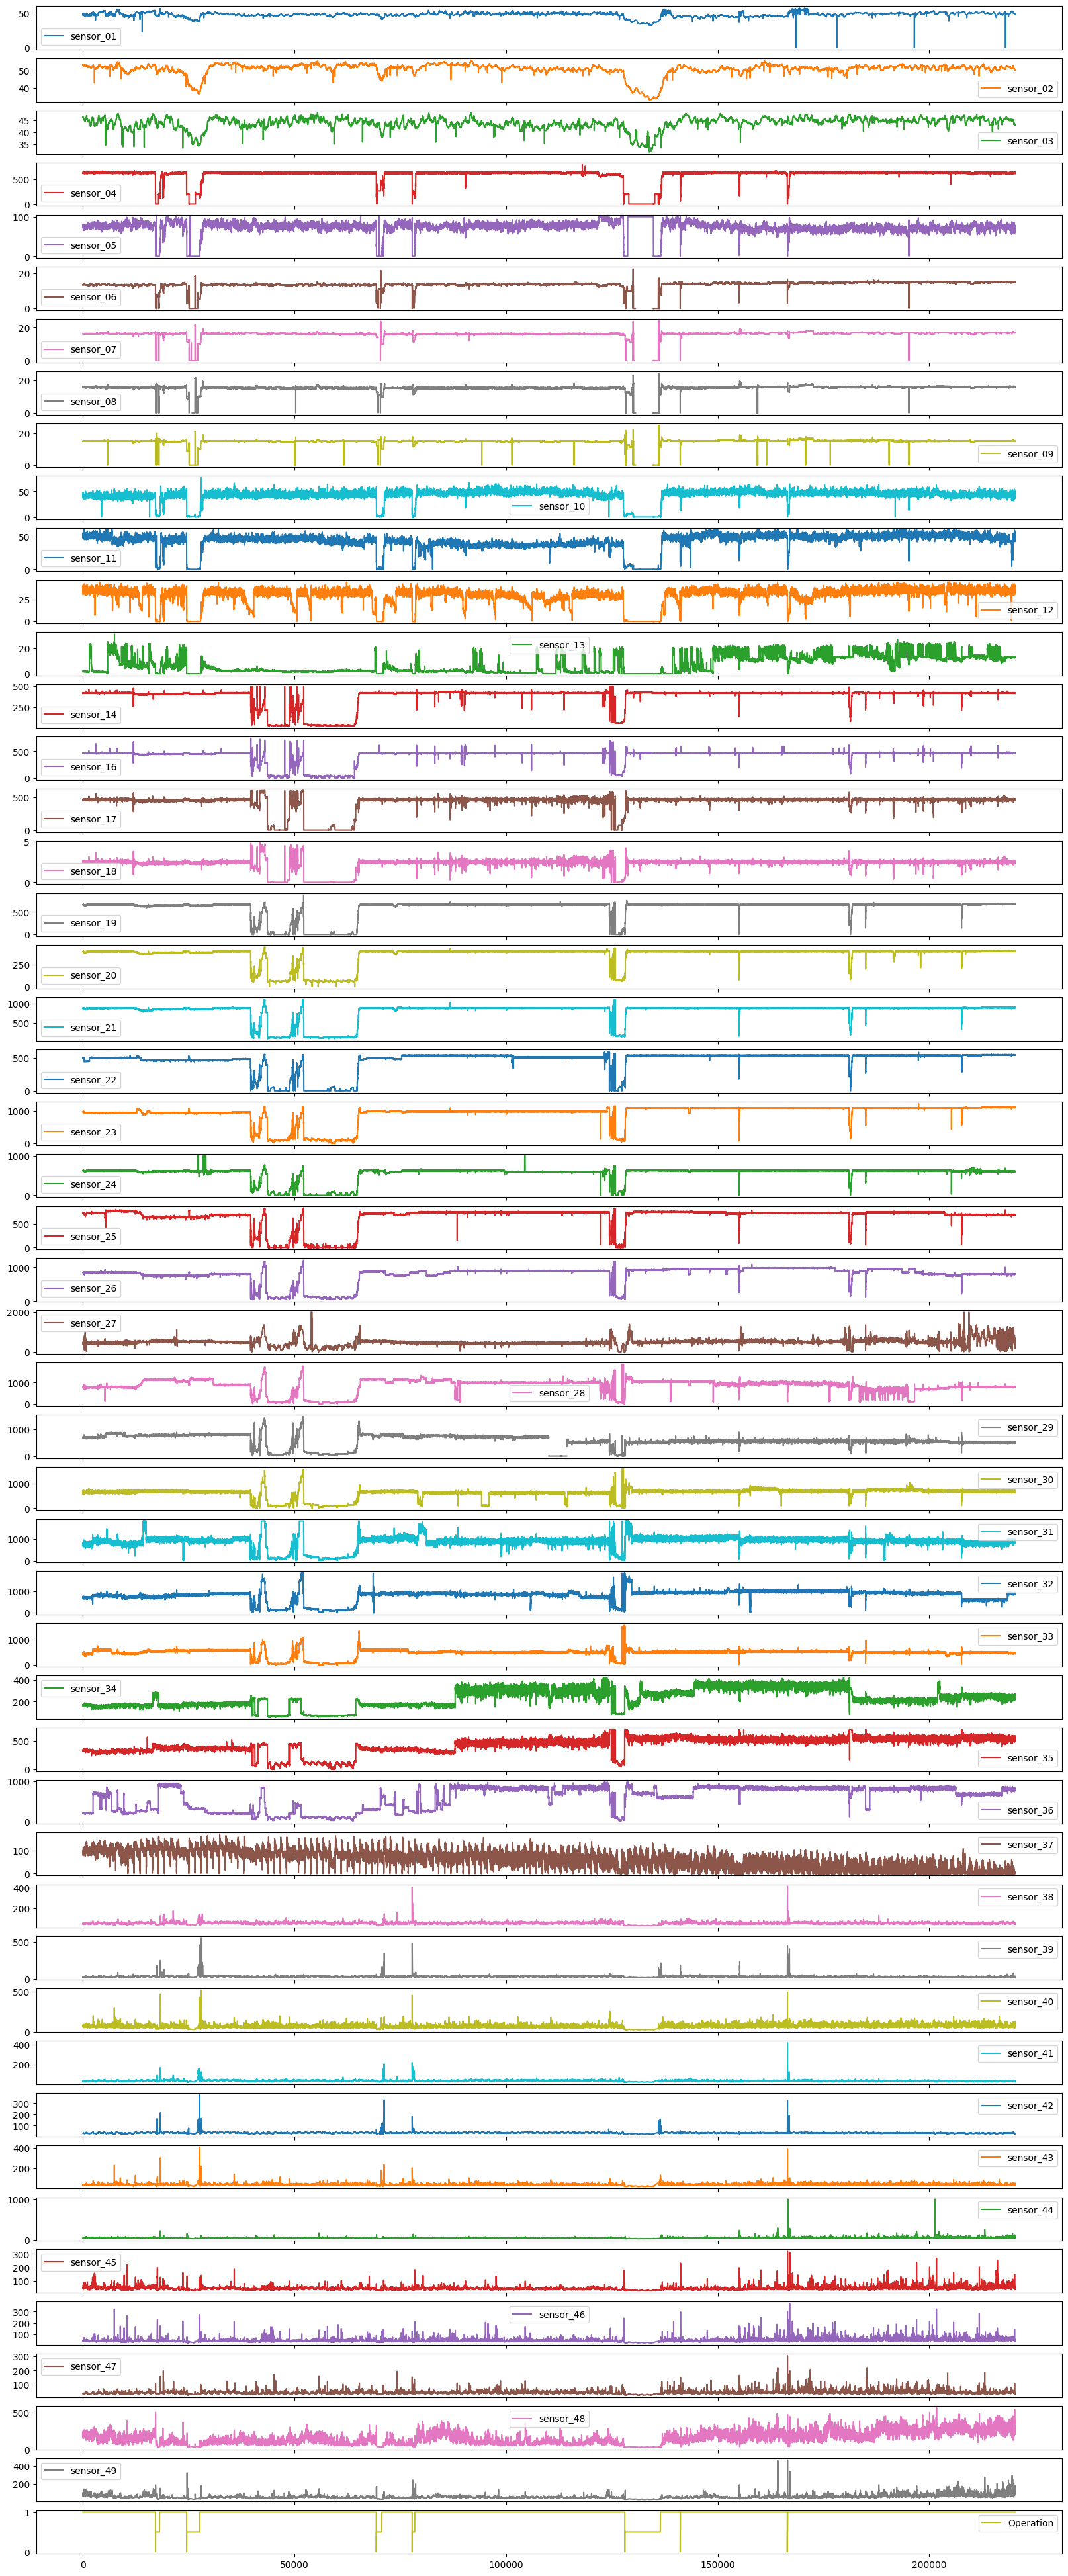

In [14]:
import matplotlib.pyplot as plt
data.plot(subplots =True, sharex = True, figsize = (20,50))

In [15]:
data.columns

Index(['sensor_01', 'sensor_02', 'sensor_03', 'sensor_04', 'sensor_05',
       'sensor_06', 'sensor_07', 'sensor_08', 'sensor_09', 'sensor_10',
       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21',
       'sensor_22', 'sensor_23', 'sensor_24', 'sensor_25', 'sensor_26',
       'sensor_27', 'sensor_28', 'sensor_29', 'sensor_30', 'sensor_31',
       'sensor_32', 'sensor_33', 'sensor_34', 'sensor_35', 'sensor_36',
       'sensor_37', 'sensor_38', 'sensor_39', 'sensor_40', 'sensor_41',
       'sensor_42', 'sensor_43', 'sensor_44', 'sensor_45', 'sensor_46',
       'sensor_47', 'sensor_48', 'sensor_49', 'machine_status', 'Operation'],
      dtype='object')

# Step 2. Assumptions and LSTM model

As analyzed above, many measurements follow the same trend. To this end, one starts by keeping only the features of interest and drop the rest. Then, one performes feature normalization to bring all values into the range [0,1]. Starting by dropping unused features, one can proceed as follows.

# Set 0: 
sensors numbers 4, 6, 7, 8, 9 will be included in the dataset.

In [16]:
df0 = pd.DataFrame(data, columns=['Operation','sensor_04', 'sensor_06', 'sensor_07', 'sensor_08', 'sensor_09'])

# Set 1: 
sensors 1, 4, 10, 14, 19, 25, 34, 38

In [17]:
df1 = pd.DataFrame(data, columns=['Operation','sensor_01', 'sensor_04', 'sensor_10', 'sensor_14', 'sensor_19', 'sensor_25'])

# Set 2: 
sensors 2, 5, 11, 16, 20, 26, 39

In [18]:
df2 = pd.DataFrame(data, columns = ['Operation','sensor_02', 'sensor_05', 'sensor_11', 'sensor_16', 'sensor_20', 'sensor_26'])

# Set 3: 
sensors 3, 6, 12, 17, 21, 28, 40

In [19]:
df3 = pd.DataFrame(data, columns = ['Operation','sensor_03', 'sensor_06', 'sensor_12', 'sensor_17', 'sensor_21', 'sensor_28'])

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
      dtype=object)

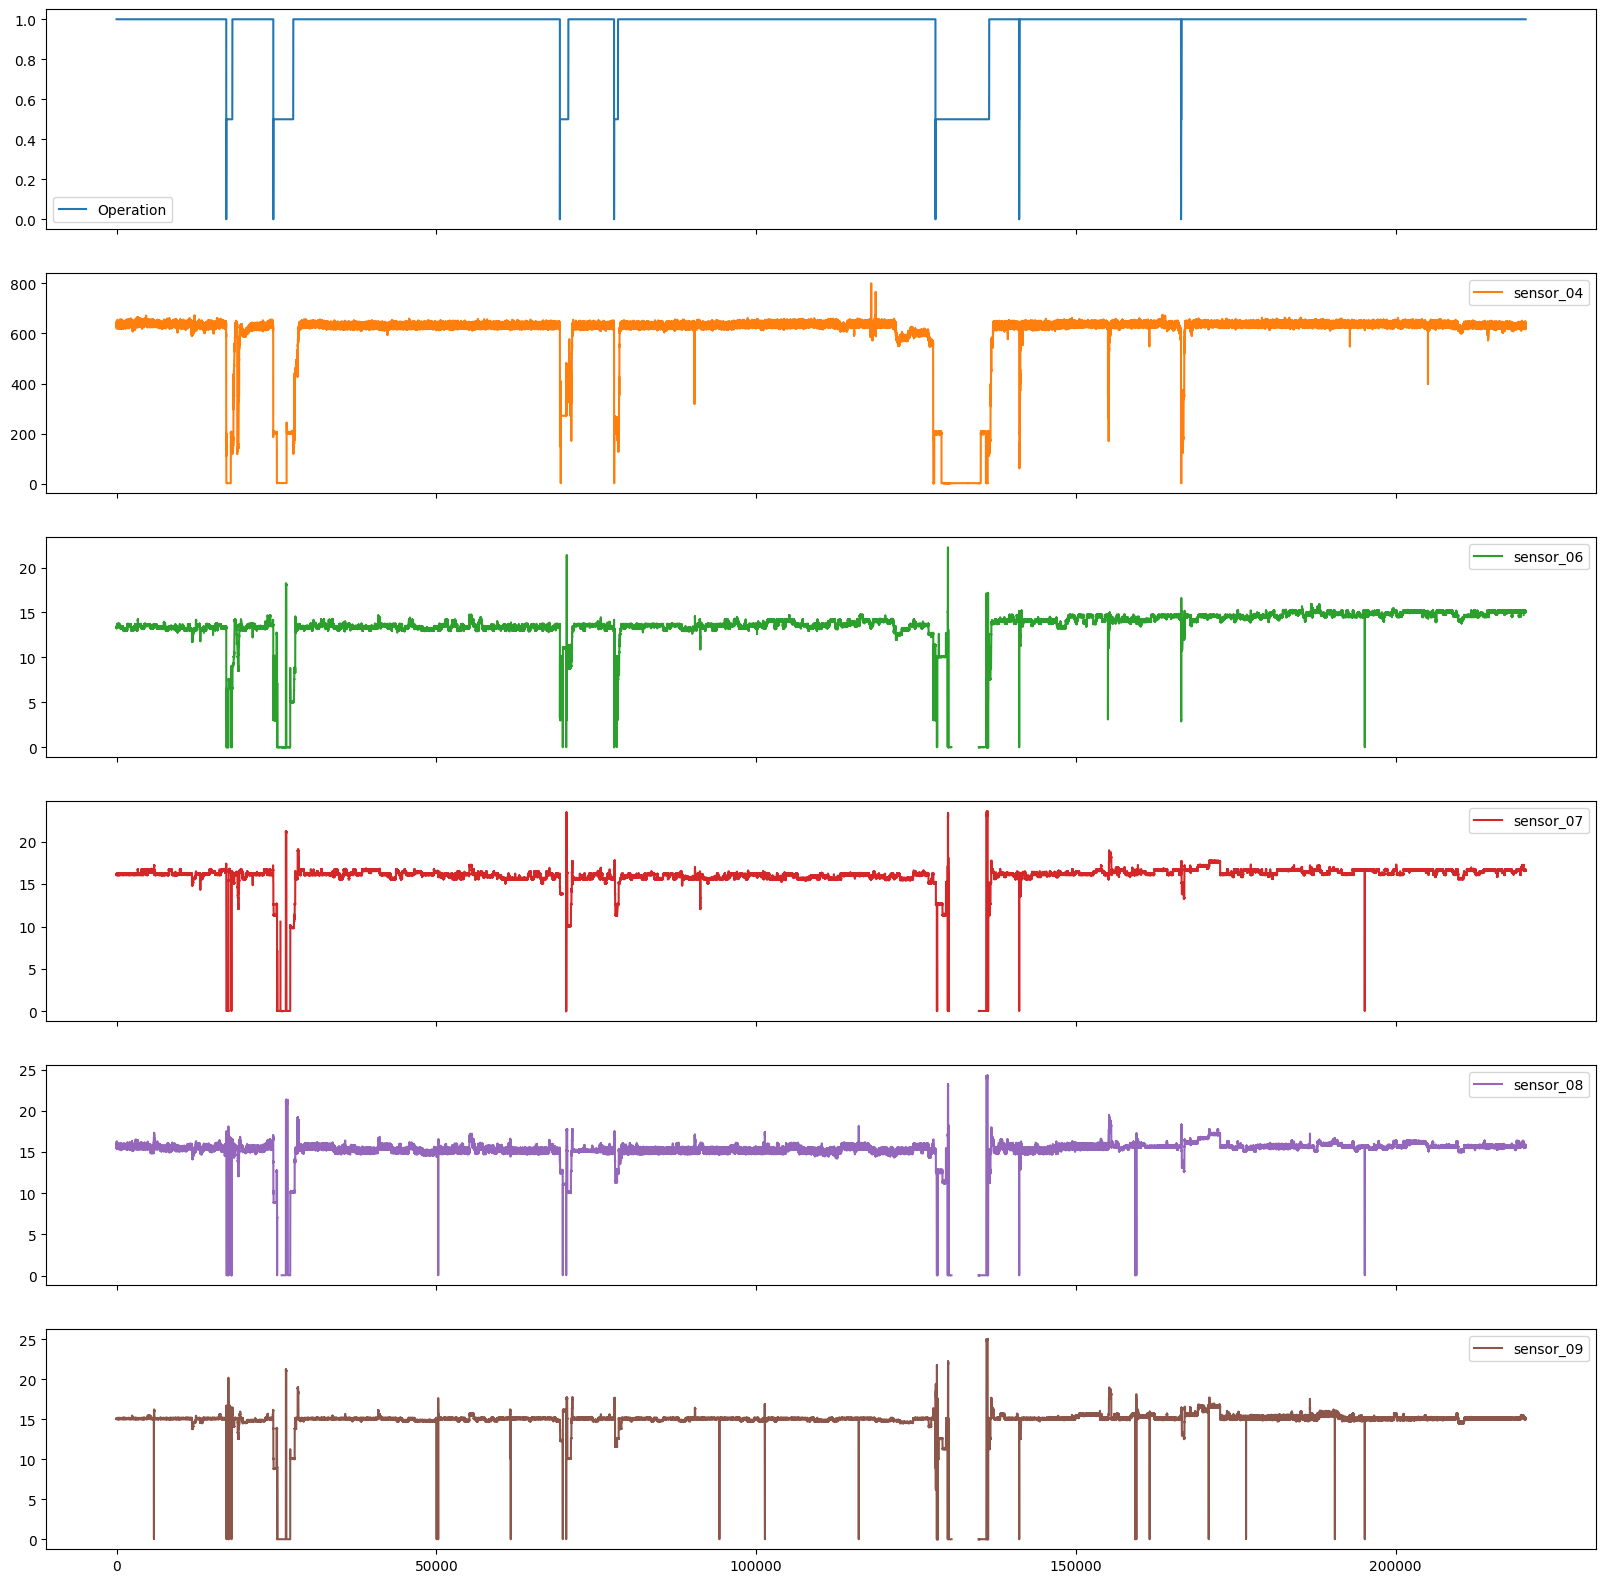

In [20]:
df0.plot(subplots =True, sharex = True, figsize = (20,20))

It seems that this time data series correlate a lot with the failure of the machine and can be a good indicator of the failure of the system, we will check it for another dataset. For now, the only concern is manipulation and prediction to test the robustness of classical methods.

In [21]:
df = df0
df.shape

(220320, 6)

# Step 3. Traing the model and implement the prediction

# Training set:

We choose 50,000 data points with 2 broken points to train the model, 

# Testing set:

the remaining 170,000 points with 5 broken states will be used to test the predictivity of the model.

In [22]:
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if type(data) is list else data.shape[1]
    dff = pd.DataFrame(data)
    cols, names = list(), list()
    for i in range(n_in, 0, -1):
        cols.append(dff.shift(-i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    for i in range(0, n_out):
        cols.append(dff.shift(-i))
        if i==0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1)) for j in range(n_vars)]        
        agg = pd.concat(cols, axis=1)
        agg.columns = names
        if dropnan:
            agg.dropna(inplace=True)
        return agg

In [24]:
from sklearn.preprocessing import MinMaxScaler

values = df.values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)
reframed = series_to_supervised(scaled, 1, 1)
r = list(range(df.shape[1]+1, 2*df.shape[1]))
reframed.drop(reframed.columns[r], axis=1, inplace=True)
reframed.head()

# Data spliting into train and test data series.
values = reframed.values
n_train_time = 50000
train = values[:n_train_time, :]
test = values[n_train_time:, :]
train_x, train_y = train[:, :-1], train[:, -1]
test_x, test_y = test[:, :-1], test[:, -1]
train_x = train_x.reshape((train_x.shape[0], 1, train_x.shape[1]))
test_x = test_x.reshape((test_x.shape[0], 1, test_x.shape[1]))

Epoch 1/50


c:\Users\mozah\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


715/715 - 7s - 10ms/step - loss: 0.0238 - val_loss: 0.0014
Epoch 2/50
715/715 - 3s - 5ms/step - loss: 0.0048 - val_loss: 0.0011
Epoch 3/50
715/715 - 4s - 5ms/step - loss: 0.0042 - val_loss: 0.0011
Epoch 4/50
715/715 - 4s - 5ms/step - loss: 0.0042 - val_loss: 0.0012
Epoch 5/50
715/715 - 3s - 5ms/step - loss: 0.0041 - val_loss: 0.0012
Epoch 6/50
715/715 - 4s - 5ms/step - loss: 0.0040 - val_loss: 0.0013
Epoch 7/50
715/715 - 4s - 5ms/step - loss: 0.0039 - val_loss: 0.0012
Epoch 8/50
715/715 - 4s - 5ms/step - loss: 0.0036 - val_loss: 0.0011
Epoch 9/50
715/715 - 4s - 5ms/step - loss: 0.0034 - val_loss: 0.0010
Epoch 10/50
715/715 - 3s - 5ms/step - loss: 0.0031 - val_loss: 9.8738e-04
Epoch 11/50
715/715 - 4s - 5ms/step - loss: 0.0029 - val_loss: 9.1228e-04
Epoch 12/50
715/715 - 3s - 5ms/step - loss: 0.0026 - val_loss: 8.4892e-04
Epoch 13/50
715/715 - 4s - 5ms/step - loss: 0.0023 - val_loss: 7.8765e-04
Epoch 14/50
715/715 - 4s - 5ms/step - loss: 0.0022 - val_loss: 7.4273e-04
Epoch 15/50
715/715

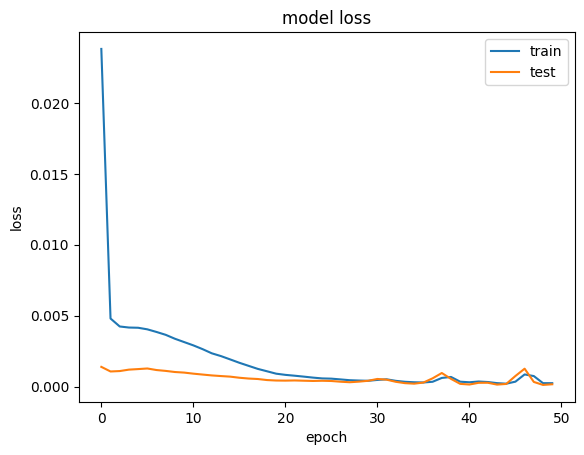

5133/5133 ━━━━━━━━━━━━━━━━━━━━ 4s 694us/step
Test RMSE: 0.013


In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error,r2_score
import matplotlib.pyplot as plt
import numpy as np

model = Sequential()
model.add(LSTM(100, input_shape=(train_x.shape[1], train_x.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# Network fitting
history = model.fit(train_x, train_y, epochs=50, batch_size=70, validation_data=(test_x, test_y), verbose=2, shuffle=False)

# Loss history plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

size = df.shape[1]

# Prediction test
yhat = model.predict(test_x)
test_x = test_x.reshape((test_x.shape[0], size))

# invert scaling for prediction
inv_yhat = np.concatenate((yhat, test_x[:, 1-size:]), axis=1)
inv_yhat = scaler.inverse_transform(inv_yhat)
inv_yhat = inv_yhat[:,0]

# invert scaling for actual
test_y = test_y.reshape((len(test_y), 1))
inv_y = np.concatenate((test_y, test_x[:, 1-size:]), axis=1)
inv_y = scaler.inverse_transform(inv_y)
inv_y = inv_y[:,0]

# calculate RMSE
rmse = np.sqrt(mean_squared_error(inv_y, inv_yhat))
print('Test RMSE: %.3f' % rmse)

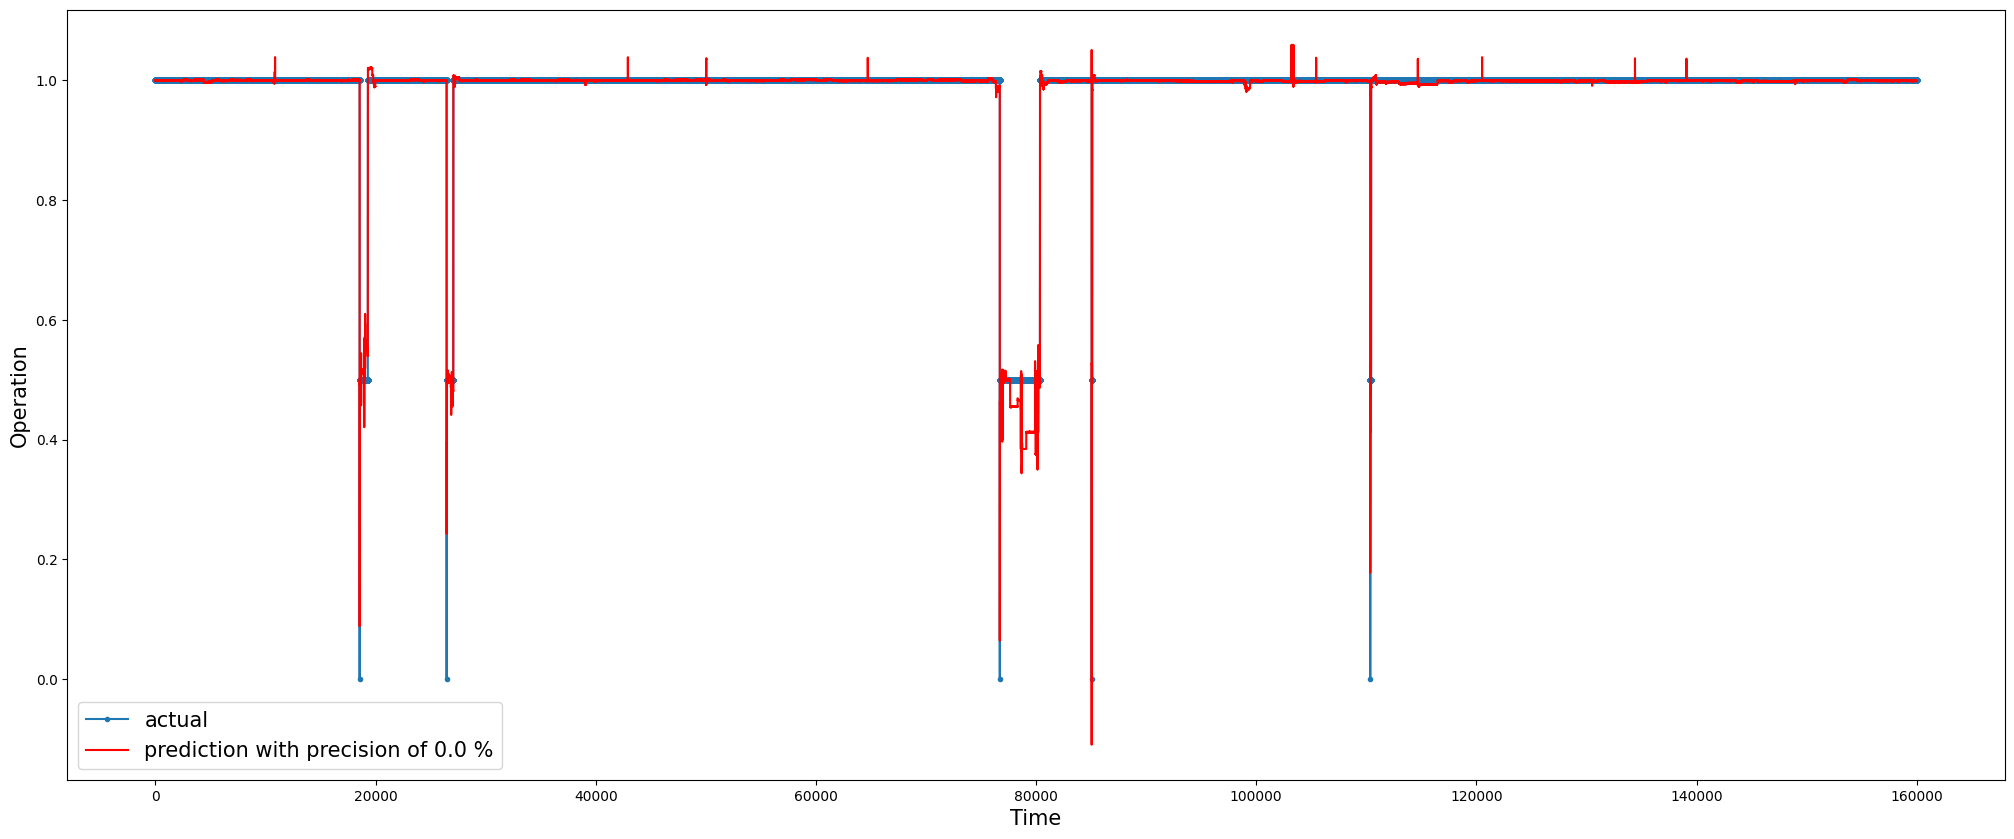

In [29]:
import numpy as np
e = np.round(sum(np.abs(inv_y[:]-inv_yhat[:]))/(sum(inv_y[:])*len(inv_y[:]))*100,2)
aa=[x for x in range(160000)]
plt.figure(figsize=(25,10)) 
plt.plot(aa, inv_y[:160000], marker='.', label="actual")
plt.plot(aa, inv_yhat[:160000], 'r', label="prediction with precision of {} %".format(e))
plt.ylabel(df.columns[0], size=15)
plt.xlabel('Time', size=15)
plt.legend(fontsize=15)
plt.show()

In [31]:
df = df2
df.shape

(220320, 7)

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >], dtype=object)

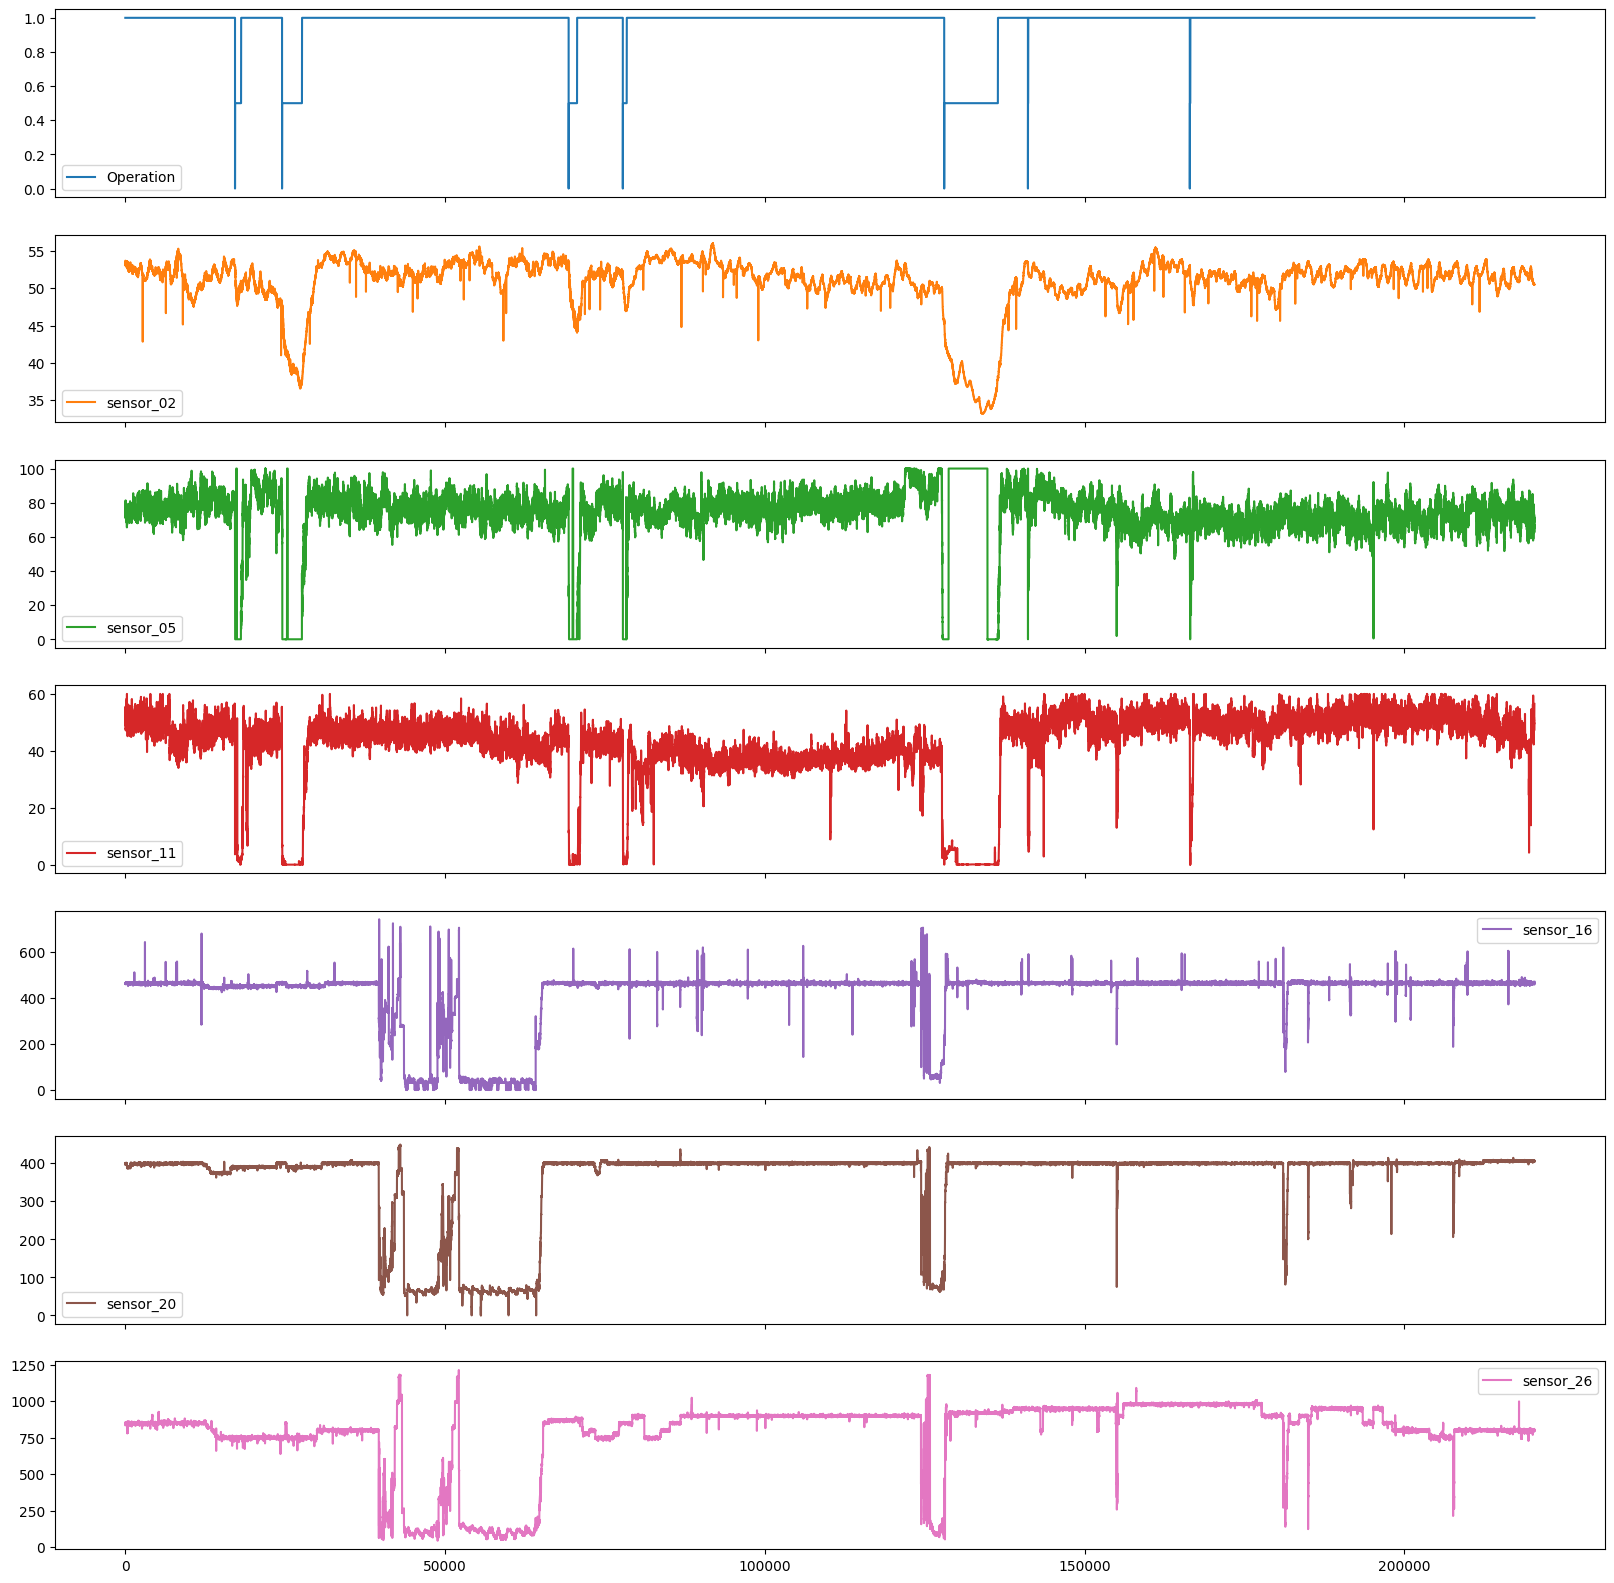

In [32]:
df2.plot(subplots =True, sharex = True, figsize = (20,20))

In [33]:
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if type(data) is list else data.shape[1]
    dff = pd.DataFrame(data)
    cols, names = list(), list()
    for i in range(n_in, 0, -1):
        cols.append(dff.shift(-i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    for i in range(0, n_out):
        cols.append(dff.shift(-i))
        if i==0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1)) for j in range(n_vars)]        
        agg = pd.concat(cols, axis=1)
        agg.columns = names
        if dropnan:
            agg.dropna(inplace=True)
        return agg

In [34]:
from sklearn.preprocessing import MinMaxScaler

values = df.values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)
reframed = series_to_supervised(scaled, 1, 1)
r = list(range(df.shape[1]+1, 2*df.shape[1]))
reframed.drop(reframed.columns[r], axis=1, inplace=True)
reframed.head()

# Data spliting into train and test data series.
values = reframed.values
n_train_time = 50000
train = values[:n_train_time, :]
test = values[n_train_time:, :]
train_x, train_y = train[:, :-1], train[:, -1]
test_x, test_y = test[:, :-1], test[:, -1]
train_x = train_x.reshape((train_x.shape[0], 1, train_x.shape[1]))
test_x = test_x.reshape((test_x.shape[0], 1, test_x.shape[1]))

Epoch 1/150


c:\Users\mozah\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


715/715 - 5s - 7ms/step - loss: 0.0257 - val_loss: 0.0101
Epoch 2/150
715/715 - 4s - 5ms/step - loss: 0.0069 - val_loss: 0.0066
Epoch 3/150
715/715 - 4s - 5ms/step - loss: 0.0061 - val_loss: 0.0060
Epoch 4/150
715/715 - 4s - 5ms/step - loss: 0.0058 - val_loss: 0.0060
Epoch 5/150
715/715 - 4s - 5ms/step - loss: 0.0055 - val_loss: 0.0061
Epoch 6/150
715/715 - 4s - 5ms/step - loss: 0.0052 - val_loss: 0.0065
Epoch 7/150
715/715 - 4s - 5ms/step - loss: 0.0049 - val_loss: 0.0070
Epoch 8/150
715/715 - 4s - 5ms/step - loss: 0.0045 - val_loss: 0.0075
Epoch 9/150
715/715 - 3s - 5ms/step - loss: 0.0041 - val_loss: 0.0081
Epoch 10/150
715/715 - 4s - 5ms/step - loss: 0.0038 - val_loss: 0.0084
Epoch 11/150
715/715 - 4s - 5ms/step - loss: 0.0034 - val_loss: 0.0087
Epoch 12/150
715/715 - 4s - 5ms/step - loss: 0.0030 - val_loss: 0.0087
Epoch 13/150
715/715 - 4s - 5ms/step - loss: 0.0027 - val_loss: 0.0089
Epoch 14/150
715/715 - 4s - 5ms/step - loss: 0.0024 - val_loss: 0.0087
Epoch 15/150
715/715 - 4s -

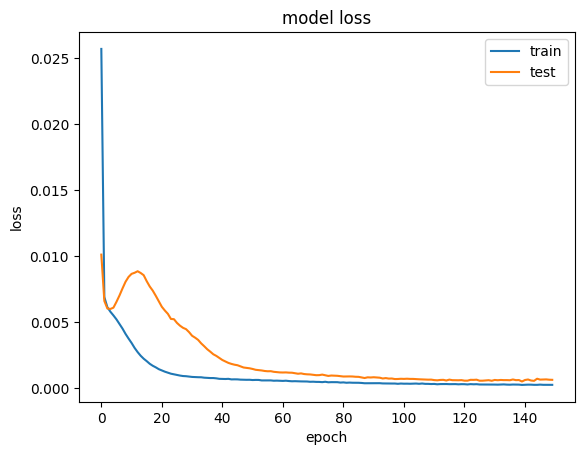

5321/5321 ━━━━━━━━━━━━━━━━━━━━ 4s 703us/step
Test RMSE: 0.025


In [35]:
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dropout
from keras.layers import Dense
from sklearn.metrics import mean_squared_error,r2_score
import matplotlib.pyplot as plt
import numpy as np

model = Sequential()
model.add(LSTM(100, input_shape=(train_x.shape[1], train_x.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# Network fitting
history = model.fit(train_x, train_y, epochs=150, batch_size=70, validation_data=(test_x, test_y), verbose=2, shuffle=False)

# Loss history plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

size = df.shape[1]

# Prediction test
yhat = model.predict(test_x)
test_x = test_x.reshape((test_x.shape[0], size))

# invert scaling for prediction
inv_yhat = np.concatenate((yhat, test_x[:, 1-size:]), axis=1)
inv_yhat = scaler.inverse_transform(inv_yhat)
inv_yhat = inv_yhat[:,0]

# invert scaling for actual
test_y = test_y.reshape((len(test_y), 1))
inv_y = np.concatenate((test_y, test_x[:, 1-size:]), axis=1)
inv_y = scaler.inverse_transform(inv_y)
inv_y = inv_y[:,0]

# calculate RMSE
rmse = np.sqrt(mean_squared_error(inv_y, inv_yhat))
print('Test RMSE: %.3f' % rmse)

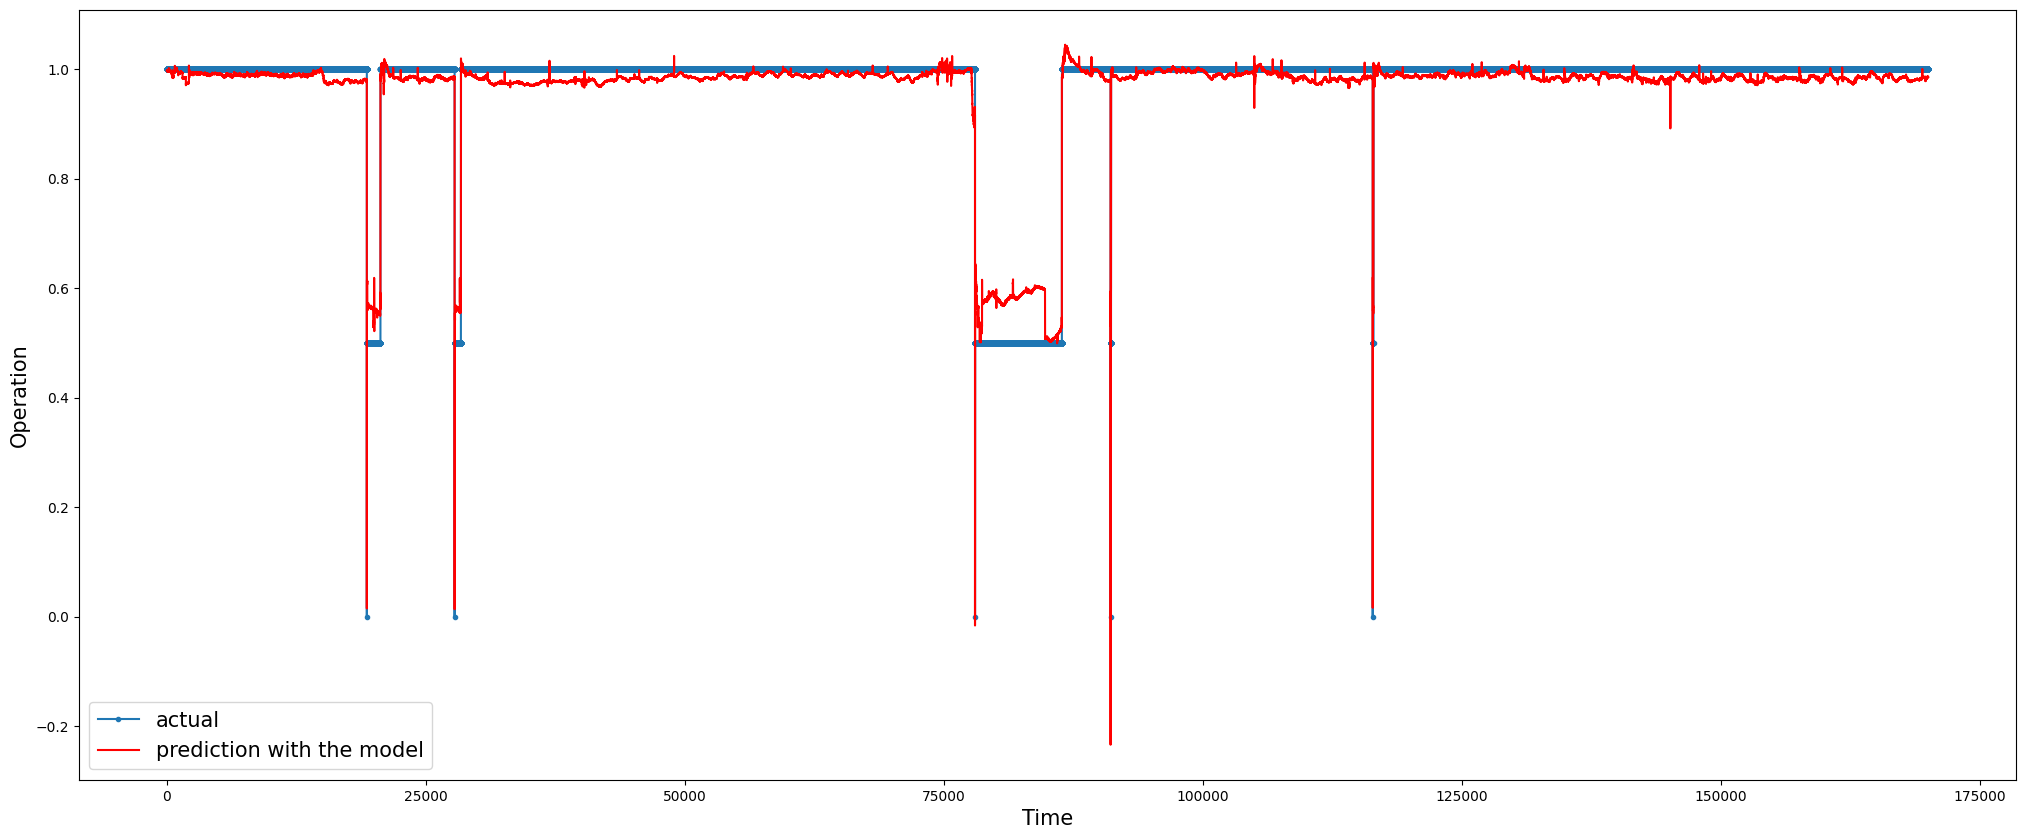

In [36]:
import numpy as np
aa=[x for x in range(170000)]
plt.figure(figsize=(25,10)) 
plt.plot(aa, inv_y[:170000], marker='.', label="actual")
plt.plot(aa, inv_yhat[:170000], 'r', label="prediction with the model")
plt.ylabel(df.columns[0], size=15)
plt.xlabel('Time', size=15)
plt.legend(fontsize=15)
plt.show()